In [1]:
import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "install", "lonboard", "ipywidgets", "matplotlib"])
from pathlib import Path
import pandas as pd
import geopandas as gpd


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [5]:
from pathlib import Path
base = Path().resolve()
while not (base / "readme.md").exists() and base != base.parent:
    base = base.parent

print("base:", base)
for f in base.rglob("*.csv"):
    print(f.relative_to(base))

base: /Users/rohanlalla/Documents/GitHub/nycha
data/processed/combined_steam_2024.csv
data/processed/nycha_residential.csv
data/processed/cleaned_nycha.csv
data/processed/cleaned_PLUTO.csv
data/processed/combined_utilities_2024.csv
data/processed/combined_heating_gas_2024.csv
data/processed/combined_electricity_2024.csv
data/processed/combined_nychares_pluto.csv
data/raw/Heating_Gas_Consumption_And_Cost_(2010_-__Sep_2025)_20260314.csv
data/raw/Steam_Consumption_And_Cost_(2010_–_Sep_2025)_20260314.csv
data/raw/NYCHA_Residential_Addresses_20260314.csv
data/raw/Primary_Land_Use_Tax_Lot_Output_(PLUTO)_20260314.csv
data/raw/Electric_Consumption_And_Cost_(2010_-_Sep_2025)_20260314.csv
data/raw/NYCHA_Development_Data_Book_20260314.csv


In [6]:
import pandas as pd
from pathlib import Path

# Find the repo root by looking for readme.md
base = Path().resolve()
while not (base / "readme.md").exists() and base != base.parent:
    base = base.parent

utilities = pd.read_csv(base / "data/processed/combined_utilities_2024.csv")
ddb       = pd.read_csv(base / "data/raw/NYCHA_Development_Data_Book_20260314.csv")

ddb_apts = ddb[['TDS#', 'CONSOLIDATED TDS#', 'TOTAL NUMBER OF APARTMENTS']].copy()
ddb_apts['tds_#'] = (
    ddb_apts['TDS#']
    .str.replace(r'\*', '', regex=True)
    .str.split(',').str[0]
    .fillna(ddb_apts['CONSOLIDATED TDS#'])
    .str.strip()
)
ddb_apts['tds_#'] = pd.to_numeric(ddb_apts['tds_#'], errors='coerce')
ddb_apts = ddb_apts.dropna(subset=['tds_#'])
ddb_apts['tds_#'] = ddb_apts['tds_#'].astype(int)
ddb_apts['ddb_apartments'] = pd.to_numeric(
    ddb_apts['TOTAL NUMBER OF APARTMENTS'].str.replace(',', ''), errors='coerce'
)
ddb_apts = ddb_apts[['tds_#', 'ddb_apartments']]

utilities = utilities.merge(ddb_apts, on='tds_#', how='left')

utilities['elec_cost_per_unit']  = utilities['electricity_current_charges'] / utilities['ddb_apartments']
utilities['gas_cost_per_unit']   = utilities['gas_current_charges']         / utilities['ddb_apartments']
utilities['steam_cost_per_unit'] = utilities['steam_current_charges']       / utilities['ddb_apartments']
utilities['total_cost_per_unit'] = utilities['total_current_charges']       / utilities['ddb_apartments']

print(f"Unmatched rows: {utilities['ddb_apartments'].isna().sum()}")

Unmatched rows: 0


In [8]:


# Calculate per-unit costs for each energy type
utilities['elec_cost_per_unit']  = utilities['electricity_current_charges'] / utilities['ddb_apartments']
utilities['gas_cost_per_unit']   = utilities['gas_current_charges']         / utilities['ddb_apartments']
utilities['steam_cost_per_unit'] = utilities['steam_current_charges']       / utilities['ddb_apartments']
utilities['total_cost_per_unit'] = utilities['total_current_charges']       / utilities['ddb_apartments']

print(utilities[['development', 'ddb_apartments', 'total_cost_per_unit']].head(10))

# Top 20 by total cost per unit
top20 = utilities.nlargest(20, 'total_current_charges_per_unit').sort_values('total_current_charges_per_unit', ascending=True)

steam_vals = top20['steam_cost_per_unit'].fillna(0).values
gas_vals = top20['gas_cost_per_unit'].fillna(0).values
elec_vals = top20['elec_cost_per_unit'].fillna(0).values
labels = top20['development'].values

                development  ddb_apartments  total_cost_per_unit
0                     SMITH            1935          2353.187245
1  TWO BRIDGES URA (SITE 7)             250          2705.408600
2                   RUTGERS             721          2262.011526
3                LA GUARDIA            1094          2658.075210
4       LA GUARDIA ADDITION             150           622.770067
5                LA GUARDIA            1094          2658.075210
6                   VLADECK            1531          1958.951228
7                   VLADECK            1531          1958.951228
8                VLADECK II             240           653.674500
9                   VLADECK            1531          1958.951228


In [36]:
import lonboard
import numpy as np
from shapely.geometry import Point
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "pyarrow", "folium"])


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


CompletedProcess(args=['/opt/homebrew/opt/python@3.11/bin/python3.11', '-m', 'pip', 'install', 'pyarrow', 'folium'], returncode=0)

In [37]:
print(lonboard.__version__)

0.16.0


In [10]:
df_grouped = utilities.groupby(['tds_#', 'development'], as_index=False).apply(
    lambda g: pd.Series({
        'ddb_apartments':               g['ddb_apartments'].iloc[0],
        'steam_current_charges':        g['steam_current_charges'].iloc[0],
        'gas_current_charges':          g['gas_current_charges'].iloc[0],
        'electricity_current_charges':  g['electricity_current_charges'].iloc[0],
        'latitude_nycha':               g['latitude_nycha'].iloc[0],
        'longitude_nycha':              g['longitude_nycha'].iloc[0],
    }),
    include_groups=False
).reset_index(drop=True)

# Filter zero/missing units
df_grouped = df_grouped[df_grouped['ddb_apartments'] > 0]

# Calculate per-unit costs
df_grouped['total_current_charges'] = (
    df_grouped['steam_current_charges'].fillna(0) +
    df_grouped['gas_current_charges'].fillna(0) +
    df_grouped['electricity_current_charges'].fillna(0)
)
df_grouped['total_current_charges_per_unit'] = df_grouped['total_current_charges']       / df_grouped['ddb_apartments']
df_grouped['steam_cost_per_unit']            = df_grouped['steam_current_charges']        / df_grouped['ddb_apartments']
df_grouped['gas_cost_per_unit']              = df_grouped['gas_current_charges']          / df_grouped['ddb_apartments']
df_grouped['elec_cost_per_unit']             = df_grouped['electricity_current_charges']  / df_grouped['ddb_apartments']

top20 = df_grouped.nlargest(20, 'total_current_charges_per_unit').sort_values(
    'total_current_charges_per_unit', ascending=True)

print(top20[['tds_#', 'development', 'ddb_apartments', 'total_current_charges_per_unit']].tail(10))

     tds_#                         development  ddb_apartments  \
108    136                              FULTON           944.0   
134    173   WSUR (SITE B) 74 WEST 92ND STREET           168.0   
87     100                             GOMPERS           474.0   
117    151  WSUR (SITE A) 120 WEST 94TH STREET            70.0   
52      60                              BARUCH          2194.0   
143    187                  AMSTERDAM ADDITION           175.0   
44      51    OCEAN BAY APARTMENTS (OCEANSIDE)           418.0   
8       11                CLASON POINT GARDENS           401.0   
71      79                       RED HOOK WEST           346.0   
164    239            CONEY ISLAND I (SITE 1B)           193.0   

     total_current_charges_per_unit  
108                     3874.911028  
134                     3959.487381  
87                      4078.965865  
117                     4223.174143  
52                      4250.143377  
143                     4507.581943  
44     

In [ ]:
import folium
from pathlib import Path

costs = top20['total_current_charges_per_unit'].values
cost_min, cost_max = costs.min(), costs.max()

def cost_to_color(cost):
    n = (cost - cost_min) / (cost_max - cost_min)
    g = int(255 * (1 - n))
    return f'#ff{g:02x}00'

m = folium.Map(location=[40.728, -73.944], zoom_start=11, tiles='CartoDB dark_matter')

for _, row in top20.iterrows():
    n = (row['total_current_charges_per_unit'] - cost_min) / (cost_max - cost_min)
    folium.CircleMarker(
        location=[row['latitude_nycha'], row['longitude_nycha']],
        radius=8 + n * 15,
        color=cost_to_color(row['total_current_charges_per_unit']),
        fill=True,
        fill_color=cost_to_color(row['total_current_charges_per_unit']),
        fill_opacity=0.85,
        tooltip=(
            f"<b>{row['development']}</b><br>"
            f"TDS#: {row['tds_#']}<br>"
            f"Units: {int(row['ddb_apartments'])}<br>"
            f"Cost/unit: ${row['total_current_charges_per_unit']:,.0f}<br>"
            f"Total charges: ${row['total_current_charges']:,.0f}"
        )
    ).add_to(m)

output_dir = base / "output"
output_dir.mkdir(parents=True, exist_ok=True)
m.save(output_dir / "nycha_top20_cost_map.html")
print(f"Saved to {output_dir / 'nycha_top20_cost_map.html'}")

Saved to /Users/rohanlalla/Documents/GitHub/nycha/output/nycha_top20_cost_map.html


In [41]:
top20[['development', 'unitstotal', 'total_current_charges_per_unit', 
       'steam_current_charges', 'gas_current_charges', 'electricity_current_charges']].sort_values(
       'total_current_charges_per_unit', ascending=False).head(5)

,development,unitstotal,total_current_charges_per_unit,steam_current_charges,gas_current_charges,electricity_current_charges
108,FULTON,378.0,38708.105926,9851264.92,0.00,4780399.12
206,HUNTS POINT AVENUE REHAB,131.0,24804.647023,0.00,2428049.78,821358.98
197,CLAREMONT REHAB (GROUP 4),158.0,16513.544051,0.00,1657097.64,952042.32
174,EAST NEW YORK CITY LINE,66.0,15839.251818,0.00,264232.92,781157.70
138,WSUR (BROWNSTONES),227.0,15078.078062,1340574.24,1367286.04,714863.44


In [7]:
print(df[['steam_mmbtu_per_unit', 'gas_mmbtu_per_unit', 'electricity_mmbtu_per_unit']].head(10))

   steam_mmbtu_per_unit  gas_mmbtu_per_unit  electricity_mmbtu_per_unit
0                   NaN           99.183971                   20.638866
1                   NaN           95.716800                   28.531208
2                   NaN          118.490569                   22.127383
3                   NaN          222.220328                   39.916438
4                   NaN                 NaN                   11.509192
5                   NaN          275.517073                   49.489893
6                   NaN          138.344956                   35.417394
7                   NaN          237.287867                   60.747555
8                   NaN                 NaN                   13.325693
9                   NaN          562.372245                  143.971706


In [15]:
# Use .iloc[0] for charges/mmbtu (repeated per BBL row) and ddb_apartments for unit counts
df_grouped = utilities.groupby(['tds_#', 'development'], as_index=False).apply(
    lambda g: pd.Series({
        'ddb_apartments':               g['ddb_apartments'].iloc[0],
        'steam_current_charges':        g['steam_current_charges'].iloc[0],
        'gas_current_charges':          g['gas_current_charges'].iloc[0],
        'electricity_current_charges':  g['electricity_current_charges'].iloc[0],
        'steam_mmbtu_per_unit':         g['steam_mmbtu_per_unit'].iloc[0],
        'gas_mmbtu_per_unit':           g['gas_mmbtu_per_unit'].iloc[0],
        'electricity_mmbtu_per_unit':   g['electricity_mmbtu_per_unit'].iloc[0],
        'latitude_nycha':               g['latitude_nycha'].iloc[0],
        'longitude_nycha':              g['longitude_nycha'].iloc[0],
    }),
    include_groups=False
).reset_index(drop=True)

df_grouped = df_grouped[df_grouped['ddb_apartments'] > 0]

df_grouped['total_current_charges'] = (
    df_grouped['steam_current_charges'].fillna(0) +
    df_grouped['gas_current_charges'].fillna(0) +
    df_grouped['electricity_current_charges'].fillna(0)
)
df_grouped['total_energy_mmbtu'] = (
    df_grouped['steam_mmbtu_per_unit'].fillna(0) +
    df_grouped['gas_mmbtu_per_unit'].fillna(0) +
    df_grouped['electricity_mmbtu_per_unit'].fillna(0)
) * df_grouped['ddb_apartments']

df_grouped['total_energy_mmbtu_per_unit']        = df_grouped['total_energy_mmbtu']    / df_grouped['ddb_apartments']
df_grouped['total_current_charges_per_unit']     = df_grouped['total_current_charges'] / df_grouped['ddb_apartments']

top20_consumption = df_grouped.nlargest(20, 'total_energy_mmbtu_per_unit').sort_values(
    'total_energy_mmbtu_per_unit', ascending=True)

print(top20_consumption[['tds_#', 'development', 'ddb_apartments', 'total_energy_mmbtu_per_unit']].tail(5))

     tds_#                development  ddb_apartments  \
197    335  CLAREMONT REHAB (GROUP 4)           150.0   
206    367   HUNTS POINT AVENUE REHAB           131.0   
58      66           SOUTH JAMAICA II           600.0   
16      21                      MARCY          1717.0   
108    136                     FULTON           944.0   

     total_energy_mmbtu_per_unit  
197                  1333.019761  
206                  1652.612031  
58                   2484.624823  
16                   3263.951872  
108                  3385.105988  


In [17]:
consumption = top20_consumption['total_energy_mmbtu_per_unit'].values
con_min, con_max = consumption.min(), consumption.max()

def consumption_to_color(val):
    n = (val - con_min) / (con_max - con_min)
    g = int(255 * (1 - n))
    return f'#ff{g:02x}00'

m = folium.Map(location=[40.728, -73.944], zoom_start=11, tiles='CartoDB dark_matter')

for _, row in top20_consumption.iterrows():
    n = (row['total_energy_mmbtu_per_unit'] - con_min) / (con_max - con_min)
    folium.CircleMarker(
        location=[row['latitude_nycha'], row['longitude_nycha']],
        radius=8 + n * 15,
        color=consumption_to_color(row['total_energy_mmbtu_per_unit']),
        fill=True,
        fill_color=consumption_to_color(row['total_energy_mmbtu_per_unit']),
        fill_opacity=0.85,
        tooltip=(
            f"<b>{row['development']}</b><br>"
            f"TDS#: {row['tds_#']}<br>"
            f"Units: {int(row['ddb_apartments'])}<br>"
            f"MMBtu/unit: {row['total_energy_mmbtu_per_unit']:,.1f}<br>"
            f"Total MMBtu: {row['total_energy_mmbtu']:,.0f}"
        )
    ).add_to(m)

output_dir = base / "output"
output_dir.mkdir(parents=True, exist_ok=True)
m.save(output_dir / "nycha_top20_consumption_map.html")
print(f"Saved to {output_dir / 'nycha_top20_consumption_map.html'}")

Saved to /Users/rohanlalla/Documents/GitHub/nycha/output/nycha_top20_consumption_map.html


In [16]:
fulton = df[df['development'] == 'FULTON']
print(fulton.shape)
print(fulton[['tds_#', 'BBL', 'unitsres', 'development', 'unitstotal', 'steam_mmbtu_per_unit', 'gas_mmbtu_per_unit', 'electricity_mmbtu_per_unit', 'steam_mmbtu_total', 'gas_mmbtu_total', 'electricity_mmbtu_total']].to_string())

(4, 26)
    tds_#         BBL  unitsres development  unitstotal  steam_mmbtu_per_unit  gas_mmbtu_per_unit  electricity_mmbtu_per_unit  steam_mmbtu_total  gas_mmbtu_total  electricity_mmbtu_total
35    136  1007140031      34.0      FULTON        34.0          1.006139e+06                 0.0                 1550.812175        34208718.94              0.0             52727.613959
36    136  1007150010     272.0      FULTON       272.0          1.257673e+05                 0.0                  193.851522        34208718.94              0.0             52727.613959
37    136  1007160017      36.0      FULTON        36.0          9.502422e+05                 0.0                 1464.655943        34208718.94              0.0             52727.613959
38    136  1007170019      36.0      FULTON        36.0          9.502422e+05                 0.0                 1464.655943        34208718.94              0.0             52727.613959


In [ ]:
# Read cleaned pluto csv
base = Path().resolve().parent
yearbuilt_df = pd.read_csv(base / "cleaned_data/combined_nychares_pluto.csv")

In [5]:
print(yearbuilt_df.columns.tolist())

['development', 'tds_#', 'building_#', 'stairhall#', 'borough_nycha', 'house_#', 'street', 'address_nycha', 'city', 'state', 'zip_code', 'bin', 'block', 'lot', 'BBL', 'census_tract_(2020)', 'neighborhood_tabulation_area_code', 'neighborhood_tabulation_area_name', 'community_district', 'city_council_district', 'state_assembly_district', 'state_senate_district', 'us_congressional_district', 'privately_managed', 'latitude_nycha', 'longitude_nycha', 'geometry', 'borough_pluto', 'tax_block', 'tax_lot', 'census_tract_2010', 'cb2010', 'council_district', 'postcode', 'policeprct', 'healtharea', 'address_pluto', 'zonedist1', 'zonedist2', 'zonedist3', 'zonedist4', 'ltdheight', 'bldgclass', 'landuse', 'easements', 'ownertype', 'ownername', 'lotarea', 'bldgarea', 'resarea', 'garagearea', 'strgearea', 'otherarea', 'areasource', 'numbldgs', 'numfloors', 'unitsres', 'unitstotal', 'lotfront', 'lotdepth', 'bldgfront', 'bldgdepth', 'proxcode', 'irrlotcode', 'lottype', 'assessland', 'assesstot', 'yearbui

In [ ]:
# Merge with consumption data
combined_df =  yearbuilt_df.merge(df, on='tds_#', how='left')

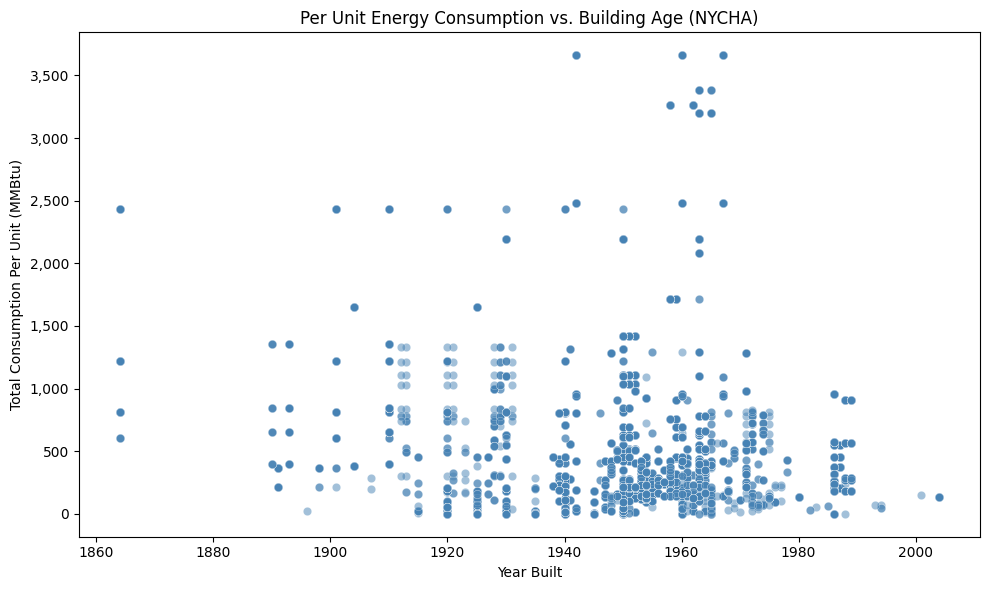

In [11]:
import matplotlib.pyplot as plt

# Build scatterplot
fig, ax = plt.subplots(figsize=(10, 6))

scatter_df = combined_df.dropna(subset=['yearbuilt', 'total_energy_mmbtu_per_unit'])
scatter_df = scatter_df[scatter_df['yearbuilt'] > 0]  # drop placeholder 0s

ax.scatter(scatter_df['yearbuilt'], scatter_df['total_energy_mmbtu_per_unit'],
           alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.3)

ax.set_xlabel('Year Built')
ax.set_ylabel('Total Consumption Per Unit (MMBtu)')
ax.set_title('Per Unit Energy Consumption vs. Building Age (NYCHA)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [30]:
import os
os.chdir('/Users/rohanlalla/Documents/GitHub/nycha')

import pandas as pd

# List your CSV files
for f in os.listdir('cleaned_data'):
    if f.endswith('.csv'):
        df = pd.read_csv(f'cleaned_data/{f}')
        print(f"\n--- {f} ---")
        print(df.columns.tolist())
        print(df.shape)
        print(df.head(2))


--- combined_steam_2024.csv ---
['development', 'tds_#', 'building_#', 'stairhall#', 'borough_nycha', 'house_#', 'street', 'address_nycha', 'city', 'state', 'zip_code', 'bin', 'block', 'lot', 'BBL', 'census_tract_(2020)', 'neighborhood_tabulation_area_code', 'neighborhood_tabulation_area_name', 'community_district', 'city_council_district', 'state_assembly_district', 'state_senate_district', 'us_congressional_district', 'privately_managed', 'latitude_nycha', 'longitude_nycha', 'geometry', 'borough_pluto', 'tax_block', 'tax_lot', 'census_tract_2010', 'cb2010', 'council_district', 'postcode', 'policeprct', 'healtharea', 'address_pluto', 'zonedist1', 'zonedist2', 'zonedist3', 'zonedist4', 'ltdheight', 'bldgclass', 'landuse', 'easements', 'ownertype', 'ownername', 'lotarea', 'bldgarea', 'resarea', 'garagearea', 'strgearea', 'otherarea', 'areasource', 'numbldgs', 'numfloors', 'unitsres', 'unitstotal', 'lotfront', 'lotdepth', 'bldgfront', 'bldgdepth', 'proxcode', 'irrlotcode', 'lottype', 'a